In [1]:
# Import necessary libraries and modules
import pandas as pd
import pandapower as pp
import pandapower.networks as pn

from simulation_interface import GridSimulation
from typing import List
from pandapower import pandapowerNet
from sim_config import GridConfig, DataCenterConfig
from grid_regions import GridRegion
from grid_observer import plot_data
from datetime import datetime, timedelta

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
# Define the grid configuration and data center configuration for the simulation
grid_config = GridConfig(
        pp_grid=pn.case118(), # type: ignore
        region=GridRegion.CA_ON
    )
data_center_config = DataCenterConfig(
    load_share=0.5, 
    onsite_overprovision_factor=1.0,
)
load_id = grid_config.add_data_center(data_center_config)

# Initialize the grid simulation interface with the defined configurations
sim_interface = GridSimulation(
    grid_configs=[grid_config],
    shifting_threshold=10.0,
    enable_weather_variation=True
)

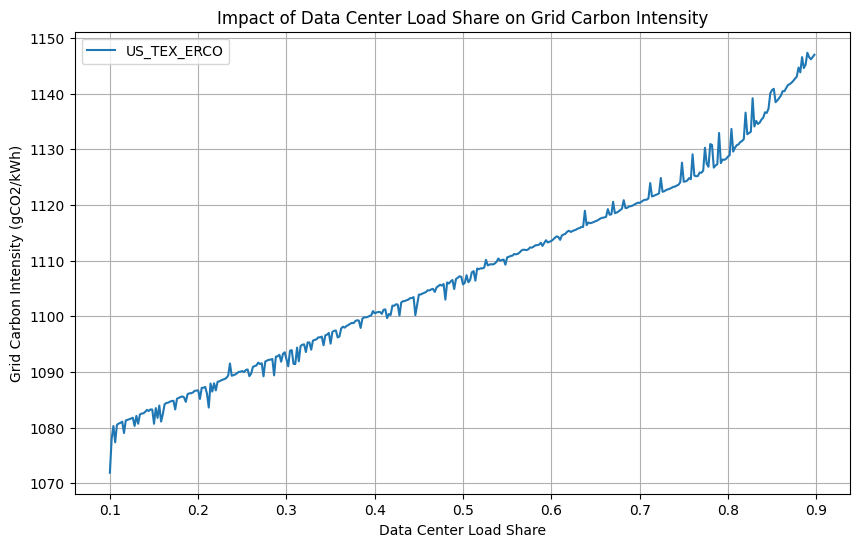

In [ ]:
# Verifies data center energy usage trend as load increases
start_date = pd.Timestamp("2024-01-01 00:00:00")
new_shares = [0.1 + 0.002 * i for i in range(400)]
SIMULATION_START_TIME: datetime = datetime.strptime('2020-08-01 00:00:00', '%Y-%m-%d %H:%M:%S')
current_time = SIMULATION_START_TIME

for share in new_shares:
    sim_interface.run_power_flow(date = current_time, observe = True)
    sim_interface.update_dc_load_share("CA_ON", [load_id], [share])
    current_time += timedelta(hours = 1)

plot_data(
    x_data = new_shares,
    y_data = sim_interface.observer._ci_data,
    labels = sim_interface.observer._grid_names,
    x_label = "Data Center Load Share",
    y_label = "Grid Carbon Intensity (gCO2/kWh)",
    title = "Impact of Data Center Load Share on Grid Carbon Intensity"
)

In [4]:
network = sim_interface._grids[0]._net
solar_p_mw, wind_p_mw, coal_p_mw = 0.0, 0.0, 0.0
total_p_mw = 0.0
for gen in network.gen.itertuples():
    gen_type = network.gen.at[gen.Index, 'source_type']
    gen_p_mw = network.gen.at[gen.Index, 'max_p_mw']
    if gen_type == 'solar':
        solar_p_mw += gen_p_mw
    elif gen_type == 'wind':
        wind_p_mw += gen_p_mw
    elif gen_type == 'coal':
        coal_p_mw += gen_p_mw 
    total_p_mw += gen_p_mw
print(f"Percentage of Solar Generation: {solar_p_mw / total_p_mw:.2%}")
print(f"Percentage of Wind Generation: {wind_p_mw / total_p_mw:.2%}")
print(f"Percentage of Coal Generation: {coal_p_mw / total_p_mw:.2%}")


Percentage of Solar Generation: 18.80%
Percentage of Wind Generation: 0.00%
Percentage of Coal Generation: 81.20%


In [5]:
display(sim_interface._grids[0]._net.res_ext_grid)

,p_mw,q_mvar
0,-93.156484,NaN


In [6]:
display(sim_interface._grids[0]._net.res_gen)

,p_mw,q_mvar,va_degree,vm_pu
0,2.365103,NaN,50.304959,1.0
1,2.000150,NaN,44.169065,1.0
2,2.264384,NaN,42.578298,1.0
3,-2.439046,NaN,44.821231,1.0
4,447.561007,NaN,60.899616,1.0
5,87.584481,NaN,42.492044,1.0
6,4.367959,NaN,34.812708,1.0
7,4.740299,NaN,34.707082,1.0
8,4.309267,NaN,33.790688,1.0
9,2.240636,NaN,36.351891,1.0


In [7]:
display(sim_interface._grids[0]._net.gen)

,name,bus,p_mw,vm_pu,sn_mva,min_q_mvar,max_q_mvar,scaling,slack,in_service,slack_weight,type,controllable,max_p_mw,min_p_mw,id_q_capability_characteristic,reactive_capability_curve,curve_style,power_limit,source_type,is_onsite_gen
0,None,0,0.0,0.955,NaN,-5.0,15.0,1.0,False,True,0.0,None,True,100.0,-inf,<NA>,False,None,100.0,coal,False
1,None,3,0.0,0.998,NaN,-300.0,300.0,1.0,False,True,0.0,None,True,100.0,-inf,<NA>,False,None,100.0,coal,False
2,None,5,0.0,0.990,NaN,-13.0,50.0,1.0,False,True,0.0,None,True,100.0,-inf,<NA>,False,None,100.0,coal,False
3,None,7,0.0,1.015,NaN,-300.0,300.0,1.0,False,True,0.0,None,True,100.0,-inf,<NA>,False,None,100.0,coal,False
4,None,9,0.0,1.050,NaN,-147.0,200.0,1.0,False,True,0.0,None,True,550.0,-inf,<NA>,False,None,550.0,coal,False
5,None,11,0.0,0.990,NaN,-35.0,120.0,1.0,False,True,0.0,None,True,185.0,-inf,<NA>,False,None,185.0,coal,False
6,None,14,0.0,0.970,NaN,-10.0,30.0,1.0,False,True,0.0,None,True,100.0,-inf,<NA>,False,None,100.0,coal,False
7,None,17,0.0,0.973,NaN,-16.0,50.0,1.0,False,True,0.0,None,True,100.0,-inf,<NA>,False,None,100.0,coal,False
8,None,18,0.0,0.962,NaN,-8.0,24.0,1.0,False,True,0.0,None,True,100.0,-inf,<NA>,False,None,100.0,coal,False
9,None,23,0.0,0.992,NaN,-300.0,300.0,1.0,False,True,0.0,None,True,100.0,-inf,<NA>,False,None,100.0,coal,False


In [8]:
display(sim_interface._grids[0]._net.load)

,name,bus,p_mw,q_mvar,const_z_p_percent,const_z_q_percent,const_i_p_percent,const_i_q_percent,sn_mva,scaling,in_service,type,controllable,is_data_center,power_limit
0,None,0,1904.658,27.0,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,True,2121.0
1,None,1,20.000,9.0,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN
2,None,2,39.000,10.0,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN
3,None,3,39.000,12.0,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN
4,None,5,52.000,22.0,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN
5,None,6,19.000,2.0,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN
6,None,7,28.000,0.0,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN
7,None,10,70.000,23.0,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN
8,None,11,47.000,10.0,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN
9,None,12,34.000,16.0,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN


In [9]:
display(sim_interface._grids[0]._net.poly_cost)

,element,et,cp0_eur,cp1_eur_per_mw,cp2_eur_per_mw2,cq0_eur,cq1_eur_per_mvar,cq2_eur_per_mvar2,cp3_eur_per_mw3
0,0,gen,100000000.0,10.0,0.0,0.0,0.0,0.0,0.0
1,1,gen,100000000.0,10.0,0.0,0.0,0.0,0.0,0.0
2,10,gen,100000000.0,10.0,0.0,0.0,0.0,0.0,0.0
3,11,gen,100000000.0,10.0,0.0,0.0,0.0,0.0,0.0
4,12,gen,100000000.0,10.0,0.0,0.0,0.0,0.0,0.0
5,13,gen,100000000.0,10.0,0.0,0.0,0.0,0.0,0.0
6,14,gen,100000000.0,10.0,0.0,0.0,0.0,0.0,0.0
7,15,gen,100000000.0,10.0,0.0,0.0,0.0,0.0,0.0
8,16,gen,100000000.0,10.0,0.0,0.0,0.0,0.0,0.0
9,17,gen,100000000.0,10.0,0.0,0.0,0.0,0.0,0.0
